# 06 — Robustness analysis (Task 2, plan §4.8)

Stress-test the four trained landmark regressors on the validation set under four controlled, lecture-motivated perturbations:

| Perturbation | Levels | Landmarks change? | Lecture link |
|---|---|---|---|
| Additive Gaussian noise | σ ∈ {0, 5, 10, 20, 40} (0–255 scale) | no | W09_L17 (HOG noise) |
| In-plane rotation       | {0, 5, 10, 20, 40}° about image centre | **yes** | W09_L17 (HOG approx. rotation invariance), W10_L19 (CNN equivariance), W10_L20 (taught invariance) |
| Brightness scaling      | × {0.5, 0.75, 1.0, 1.25, 1.5} (clip)  | no | W09_L17 (HOG gradients ignore bias) |
| Isotropic scale         | × {0.7, 0.85, 1.0, 1.15, 1.3}         | **yes** | W10_L19 (no scale equivariance) |

**No retraining.** Models are loaded from `models/`. NME is computed in the 64×64 working frame on perturbed ground truth — since NME is normalised by inter-eye distance, the frame is irrelevant for relative comparisons (and using the perturbed GT in the same frame as the prediction is required for the metric to be well-defined under rotation/scale, as the plan flags).

Aug-vs-noaug rotation plot is the §9 originality angle: W10_L20 predicts the augmented CNN curve should be flatter as rotation grows.

In [1]:
import csv
import json
import sys
from pathlib import Path

import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt
import torch
from skimage.feature import hog as skhog

NB_DIR = Path.cwd()
sys.path.insert(0, str(NB_DIR / 'src'))
from preprocess_img import load_data, preprocess_image, DEFAULT_CONFIG  # noqa: E402
from landmarks import nme, ced_curve  # noqa: E402
from cnn import FaceCNN, predict_landmarks  # noqa: E402

FIG_DIR = NB_DIR / 'figures'
MODELS_DIR = NB_DIR / 'models'
RESULTS_DIR = NB_DIR / 'results'
for d in (FIG_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams['font.size'] = 11
print('device =', device)

device = cpu


## Load val set in the 64×64 frame

In [2]:
data = load_data()
train_images = data['train_images']
train_points = data['train_points']

split = np.load(NB_DIR / 'data' / 'split_indices.npz')
val_idx = split['val_idx']

H_out, W_out = DEFAULT_CONFIG['out_size']
X_val_64 = np.zeros((val_idx.size, H_out, W_out), dtype=np.float32)
y_val_64 = np.zeros((val_idx.size, 5, 2), dtype=np.float32)
for i, idx in enumerate(val_idx):
    out, lm_scaled = preprocess_image(train_images[idx], train_points[idx], DEFAULT_CONFIG)
    X_val_64[i] = out
    y_val_64[i] = lm_scaled

print(f'X_val_64: {X_val_64.shape}  range=[{X_val_64.min():.3f}, {X_val_64.max():.3f}]')
print(f'y_val_64: {y_val_64.shape}')

X_val_64: (390, 64, 64)  range=[0.000, 1.000]
y_val_64: (390, 5, 2)


## Perturbation helpers

Images are float32 in [0, 1]; σ is specified on the 0–255 scale (per the plan) and rescaled internally. For rotation and scale the affine matrix is applied to both image (`cv2.warpAffine`, `BORDER_REPLICATE` to match the augmentation convention in `src/cnn.py`) and landmarks (homogeneous multiply by the same `M`).

In [3]:
def _affine_apply(img, lm, M):
    H, W = img.shape[:2]
    out = cv2.warpAffine(img, M, (W, H), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
    ones = np.ones((lm.shape[0], 1), dtype=np.float32)
    homo = np.concatenate([lm.astype(np.float32), ones], axis=1)
    new_lm = homo @ M.T.astype(np.float32)
    return out.astype(img.dtype, copy=False), new_lm


def apply_noise(img, lm, sigma_255, rng):
    """Add Gaussian noise with σ given on 0–255 scale; image is in [0, 1]."""
    sigma = float(sigma_255) / 255.0
    if sigma == 0.0:
        return img.copy(), lm.copy()
    noise = rng.normal(0.0, sigma, size=img.shape).astype(np.float32)
    return np.clip(img + noise, 0.0, 1.0).astype(np.float32), lm.copy()


def apply_rotation(img, lm, deg):
    if deg == 0:
        return img.copy(), lm.copy()
    H, W = img.shape[:2]
    M = cv2.getRotationMatrix2D(((W - 1) * 0.5, (H - 1) * 0.5), float(deg), 1.0)
    return _affine_apply(img, lm, M)


def apply_brightness(img, lm, factor):
    out = np.clip(img.astype(np.float32) * float(factor), 0.0, 1.0).astype(np.float32)
    return out, lm.copy()


def apply_scale(img, lm, factor):
    if factor == 1.0:
        return img.copy(), lm.copy()
    H, W = img.shape[:2]
    M = cv2.getRotationMatrix2D(((W - 1) * 0.5, (H - 1) * 0.5), 0.0, float(factor))
    return _affine_apply(img, lm, M)


def perturb_set(X, Y, kind, level, rng):
    """Apply one (perturbation, level) over the full set. Returns (Xp, Yp)."""
    N = X.shape[0]
    Xp = np.empty_like(X)
    Yp = np.empty_like(Y)
    for n in range(N):
        if kind == 'noise':
            Xp[n], Yp[n] = apply_noise(X[n], Y[n], level, rng)
        elif kind == 'rotation':
            Xp[n], Yp[n] = apply_rotation(X[n], Y[n], level)
        elif kind == 'brightness':
            Xp[n], Yp[n] = apply_brightness(X[n], Y[n], level)
        elif kind == 'scale':
            Xp[n], Yp[n] = apply_scale(X[n], Y[n], level)
        else:
            raise ValueError(kind)
    return Xp, Yp


# Quick sanity check.
_rng = np.random.default_rng(SEED)
for kind, lvl in [('noise', 20), ('rotation', 20), ('brightness', 0.5), ('scale', 0.7)]:
    xp, yp = perturb_set(X_val_64[:2], y_val_64[:2], kind, lvl, _rng)
    print(f'{kind:>10s} lvl={lvl}: img range [{xp.min():.3f},{xp.max():.3f}]  lm[0] = {yp[0,0]}')

     noise lvl=20: img range [0.000,1.000]  lm[0] = [20.043226 25.552616]
  rotation lvl=20: img range [0.030,0.916]  lm[0] = [18.700031 29.829735]
brightness lvl=0.5: img range [0.012,0.463]  lm[0] = [20.043226 25.552616]
     scale lvl=0.7: img range [0.033,0.910]  lm[0] = [23.480259 27.33683 ]


## Load the four trained models

- **HOG + Ridge** — `models/hog_ridge.joblib` (sklearn Ridge on HOG features of the full 64×64 image).
- **Cascaded regression** — `models/cascaded.joblib` (K stage-specific Ridges over pose-indexed patch HOG features, initialised from `mean_face_64`).
- **CNN no-aug / CNN aug** — `models/cnn_noaug.pt` / `models/cnn_aug.pt` (`FaceCNN` state-dicts).

In [4]:
hog_bundle = joblib.load(MODELS_DIR / 'hog_ridge.joblib')
hog_model = hog_bundle['model']
HOG_KW = hog_bundle['hog_kw']

cas_bundle = joblib.load(MODELS_DIR / 'cascaded.joblib')
CAS_REGS = cas_bundle['regressors']
CAS_PATCH = int(cas_bundle['patch_size'])
CAS_HOG_KW = cas_bundle['hog_patch_kw']
CAS_INIT = cas_bundle['mean_face_64'].astype(np.float32)

cnn_noaug = FaceCNN().to(device)
cnn_noaug.load_state_dict(torch.load(MODELS_DIR / 'cnn_noaug.pt', map_location=device))
cnn_noaug.eval()

cnn_aug = FaceCNN().to(device)
cnn_aug.load_state_dict(torch.load(MODELS_DIR / 'cnn_aug.pt', map_location=device))
cnn_aug.eval()

print('loaded:', list(hog_bundle.keys()), '|', list(cas_bundle.keys())[:4], '| cnn_aug', sum(p.numel() for p in cnn_aug.parameters()), 'params')

loaded: ['model', 'alpha', 'config', 'hog_kw', 'scale_back'] | ['regressors', 'K', 'patch_size', 'alpha'] | cnn_aug 767722 params


## Per-model predict on a 64×64 image stack

In [5]:
def _extract_patch_hog(img, point, patch_size, hog_kw):
    H, W = img.shape
    half = patch_size // 2
    cx = int(round(float(point[0]))); cy = int(round(float(point[1])))
    x0, x1 = cx - half, cx - half + patch_size
    y0, y1 = cy - half, cy - half + patch_size
    pad_left = max(0, -x0); pad_top = max(0, -y0)
    pad_right = max(0, x1 - W); pad_bot = max(0, y1 - H)
    if pad_left or pad_top or pad_right or pad_bot:
        img_p = np.pad(img, ((pad_top, pad_bot), (pad_left, pad_right)), mode='edge')
        x0 += pad_left; x1 += pad_left; y0 += pad_top; y1 += pad_top
    else:
        img_p = img
    return skhog(img_p[y0:y1, x0:x1], **hog_kw)


def _pose_indexed_features(imgs, shapes, patch_size, hog_kw):
    N = imgs.shape[0]
    d = _extract_patch_hog(imgs[0], shapes[0, 0], patch_size, hog_kw).shape[0]
    F = np.empty((N, 5 * d), dtype=np.float32)
    for n in range(N):
        F[n] = np.concatenate([_extract_patch_hog(imgs[n], shapes[n, k], patch_size, hog_kw)
                               for k in range(5)])
    return F


def predict_hog_ridge(X):
    feats = np.stack([skhog(X[i], **HOG_KW) for i in range(X.shape[0])])
    return hog_model.predict(feats).reshape(-1, 5, 2).astype(np.float32)


def predict_cascaded(X):
    N = X.shape[0]
    s = np.broadcast_to(CAS_INIT, (N, 5, 2)).astype(np.float32).copy()
    for reg in CAS_REGS:
        F = _pose_indexed_features(X, s, CAS_PATCH, CAS_HOG_KW)
        s = s + reg.predict(F).reshape(-1, 5, 2).astype(np.float32)
    return s


def predict_cnn(model, X):
    return predict_landmarks(model, X, device)


MODELS = {
    'HOG+Ridge': lambda X: predict_hog_ridge(X),
    'Cascaded':  lambda X: predict_cascaded(X),
    'CNN-noaug': lambda X: predict_cnn(cnn_noaug, X),
    'CNN-aug':   lambda X: predict_cnn(cnn_aug, X),
}

# Sanity: clean val NME for each model.
for name, fn in MODELS.items():
    p = fn(X_val_64)
    print(f'  {name:<10s} clean val mean NME = {float(np.nanmean(nme(p, y_val_64))):.4f}')

  HOG+Ridge  clean val mean NME = 0.0564


  Cascaded   clean val mean NME = 0.0510


  CNN-noaug  clean val mean NME = 0.0758


  CNN-aug    clean val mean NME = 0.0832


## Sweep — all (model, perturbation, level) combinations

Save the full table to `results/robustness.csv` and stash per-image NMEs in memory for downstream CED / band plots.

In [6]:
PERTURBATIONS = {
    'noise':      [0, 5, 10, 20, 40],
    'rotation':   [0, 5, 10, 20, 40],
    'brightness': [0.5, 0.75, 1.0, 1.25, 1.5],
    'scale':      [0.7, 0.85, 1.0, 1.15, 1.3],
}

results = []            # rows for the CSV
nme_grid = {}           # (model, perturbation, level) -> per-image NME vector

for kind, levels in PERTURBATIONS.items():
    for lvl in levels:
        rng = np.random.default_rng(SEED)  # noise is the only stochastic one — reseed per level for reproducibility
        Xp, Yp = perturb_set(X_val_64, y_val_64, kind, lvl, rng)
        for name, fn in MODELS.items():
            pred = fn(Xp)
            nm = nme(pred, Yp)
            nme_grid[(name, kind, lvl)] = nm
            results.append({
                'model': name,
                'perturbation': kind,
                'level': lvl,
                'mean_nme': float(np.nanmean(nm)),
                'median_nme': float(np.nanmedian(nm)),
                'n': int(np.sum(~np.isnan(nm))),
            })
            print(f'  {name:<10s}  {kind:<10s} lvl={lvl:<5}  mean={results[-1]["mean_nme"]:.4f}  med={results[-1]["median_nme"]:.4f}')

csv_path = RESULTS_DIR / 'robustness.csv'
with open(csv_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=['model', 'perturbation', 'level', 'mean_nme', 'median_nme', 'n'])
    w.writeheader()
    w.writerows(results)
print('saved', csv_path)

  HOG+Ridge   noise      lvl=0      mean=0.0564  med=0.0503


  Cascaded    noise      lvl=0      mean=0.0510  med=0.0442


  CNN-noaug   noise      lvl=0      mean=0.0758  med=0.0688


  CNN-aug     noise      lvl=0      mean=0.0832  med=0.0781


  HOG+Ridge   noise      lvl=5      mean=0.0589  med=0.0521


...

  CNN-aug     scale      lvl=1.15   mean=0.0836  med=0.0791


  HOG+Ridge   scale      lvl=1.3    mean=0.1053  med=0.0997


  Cascaded    scale      lvl=1.3    mean=0.0961  med=0.0887


  CNN-noaug   scale      lvl=1.3    mean=0.1364  med=0.1321


  CNN-aug     scale      lvl=1.3    mean=0.1064  med=0.1040
saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/results/robustness.csv


## Per-perturbation curves (one figure each, four models on common axes)

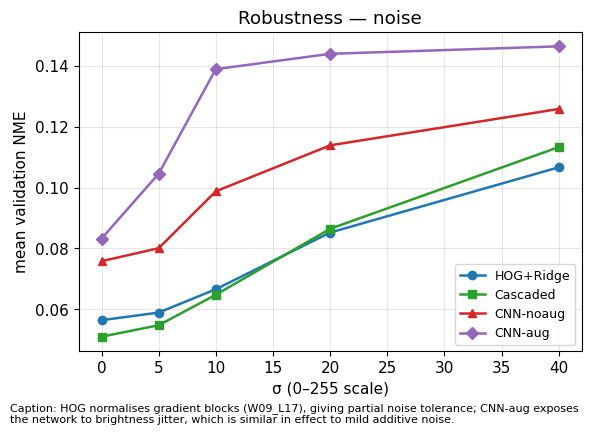

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/figures/robustness_noise.png


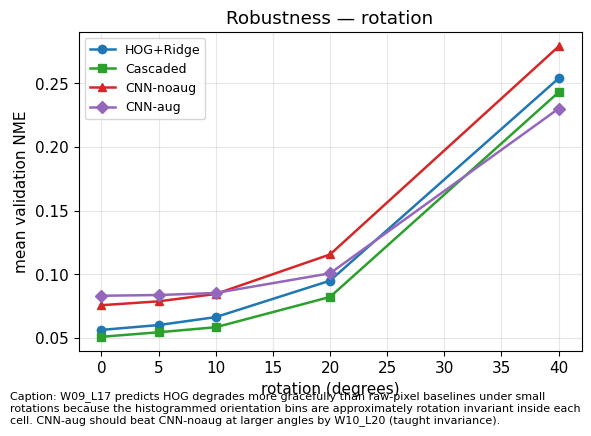

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/figures/robustness_rotation.png


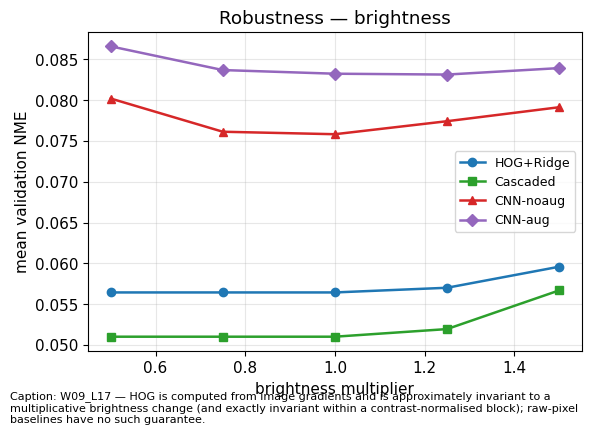

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/figures/robustness_brightness.png


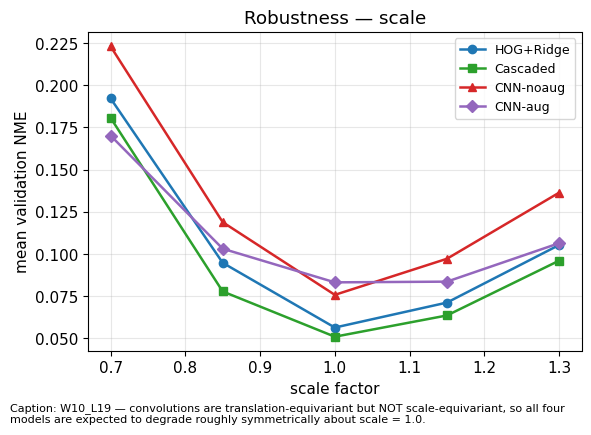

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/figures/robustness_scale.png


In [7]:
MODEL_STYLE = {
    'HOG+Ridge': dict(color='#1f77b4', marker='o'),
    'Cascaded':  dict(color='#2ca02c', marker='s'),
    'CNN-noaug': dict(color='#d62728', marker='^'),
    'CNN-aug':   dict(color='#9467bd', marker='D'),
}

def _curve_plot(kind, xlabel, caption, outpath):
    levels = PERTURBATIONS[kind]
    fig, ax = plt.subplots(figsize=(6.0, 4.2))
    for name in MODELS:
        means = [float(np.nanmean(nme_grid[(name, kind, lv)])) for lv in levels]
        ax.plot(levels, means, label=name, linewidth=1.8, **MODEL_STYLE[name])
    ax.set_xlabel(xlabel)
    ax.set_ylabel('mean validation NME')
    ax.set_title(f'Robustness — {kind}')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    fig.text(0.02, -0.02, caption, fontsize=8, wrap=True)
    fig.tight_layout()
    fig.savefig(outpath, bbox_inches='tight')
    plt.show()
    print('saved', outpath)

_curve_plot('noise', 'σ (0–255 scale)',
    'Caption: HOG normalises gradient blocks (W09_L17), giving partial noise tolerance; CNN-aug exposes the network to brightness jitter, which is similar in effect to mild additive noise.',
    FIG_DIR / 'robustness_noise.png')

_curve_plot('rotation', 'rotation (degrees)',
    'Caption: W09_L17 predicts HOG degrades more gracefully than raw-pixel baselines under small rotations because the histogrammed orientation bins are approximately rotation invariant inside each cell. CNN-aug should beat CNN-noaug at larger angles by W10_L20 (taught invariance).',
    FIG_DIR / 'robustness_rotation.png')

_curve_plot('brightness', 'brightness multiplier',
    'Caption: W09_L17 — HOG is computed from image gradients and is approximately invariant to a multiplicative brightness change (and exactly invariant within a contrast-normalised block); raw-pixel baselines have no such guarantee.',
    FIG_DIR / 'robustness_brightness.png')

_curve_plot('scale', 'scale factor',
    'Caption: W10_L19 — convolutions are translation-equivariant but NOT scale-equivariant, so all four models are expected to degrade roughly symmetrically about scale = 1.0.',
    FIG_DIR / 'robustness_scale.png')

## Headline CED at the worst perturbation level (4 subplots × 4 models)

worst levels: {'noise': 40, 'rotation': 40, 'brightness': 1.5, 'scale': 0.7}


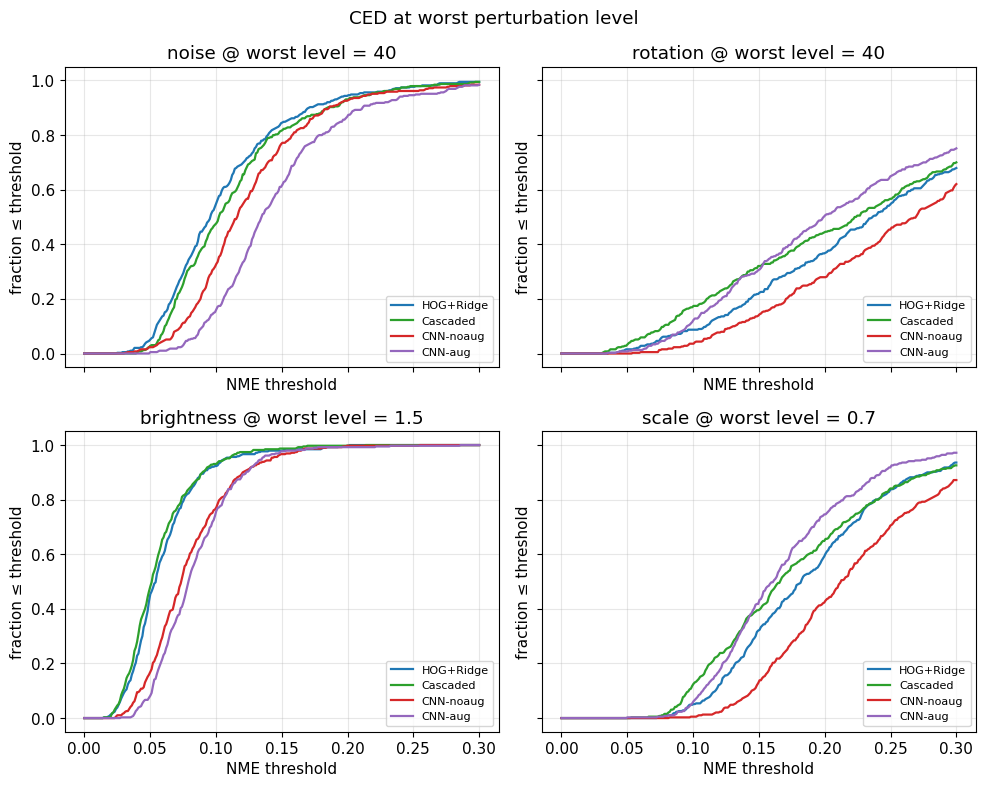

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/figures/robustness_ced_worst.png


In [8]:
# Choose the level with the largest mean NME (across all models) per perturbation as 'worst'.
worst_levels = {}
for kind, levels in PERTURBATIONS.items():
    best_lv, best_score = None, -np.inf
    for lv in levels:
        s = np.mean([float(np.nanmean(nme_grid[(n, kind, lv)])) for n in MODELS])
        if s > best_score:
            best_score, best_lv = s, lv
    worst_levels[kind] = best_lv
print('worst levels:', worst_levels)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
for ax, (kind, lv) in zip(axes.flat, worst_levels.items()):
    for name in MODELS:
        thr, frac = ced_curve(nme_grid[(name, kind, lv)], max_err=0.30, n=300)
        ax.plot(thr, frac, label=name, linewidth=1.6, color=MODEL_STYLE[name]['color'])
    ax.set_title(f'{kind} @ worst level = {lv}')
    ax.set_xlabel('NME threshold'); ax.set_ylabel('fraction ≤ threshold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='lower right')
fig.suptitle('CED at worst perturbation level')
fig.tight_layout()
fig.savefig(FIG_DIR / 'robustness_ced_worst.png', bbox_inches='tight')
plt.show()
print('saved', FIG_DIR / 'robustness_ced_worst.png')

## Aug vs no-aug — the §9 originality angle (rotation)

Two curves on common axes with shaded ±1 std bands across the val set per level. W10_L20 prediction: **the augmented model's curve should be flatter as rotation grows** because the network was explicitly shown rotated examples during training (taught invariance). If we don't see flattening, we say so.

  Δ(NME, 0→40°)  noaug=0.2031  aug=0.1469  →  aug curve IS flatter (as W10_L20 predicts)


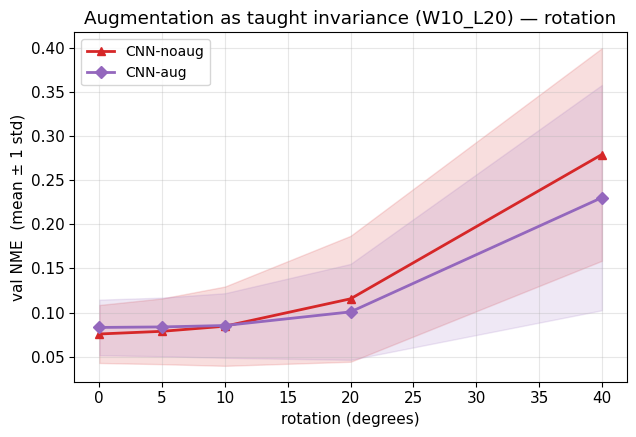

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/figures/aug_vs_noaug_rotation.png


In [9]:
levels = PERTURBATIONS['rotation']
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for name in ['CNN-noaug', 'CNN-aug']:
    means, stds = [], []
    for lv in levels:
        v = nme_grid[(name, 'rotation', lv)]
        means.append(float(np.nanmean(v)))
        stds.append(float(np.nanstd(v)))
    means = np.array(means); stds = np.array(stds)
    style = MODEL_STYLE[name]
    ax.plot(levels, means, label=name, linewidth=2.0, **style)
    ax.fill_between(levels, means - stds, means + stds, color=style['color'], alpha=0.15)

# Compare slopes (mean NME at largest rotation − clean) to quantify 'flatness'.
deltas = {}
for name in ['CNN-noaug', 'CNN-aug']:
    clean = float(np.nanmean(nme_grid[(name, 'rotation', 0)]))
    worst = float(np.nanmean(nme_grid[(name, 'rotation', levels[-1])]))
    deltas[name] = worst - clean
verdict = ('aug curve IS flatter (as W10_L20 predicts)'
           if deltas['CNN-aug'] < deltas['CNN-noaug']
           else 'aug curve is NOT flatter — predicted W10_L20 effect did NOT appear here')
print(f'  Δ(NME, 0→{levels[-1]}°)  noaug={deltas["CNN-noaug"]:.4f}  aug={deltas["CNN-aug"]:.4f}  →  {verdict}')

ax.set_xlabel('rotation (degrees)')
ax.set_ylabel('val NME  (mean ± 1 std)')
ax.set_title('Augmentation as taught invariance (W10_L20) — rotation')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'aug_vs_noaug_rotation.png', bbox_inches='tight')
plt.show()
print('saved', FIG_DIR / 'aug_vs_noaug_rotation.png')

## §2.3 robustness summary

> **Robustness.** We stress-tested HOG+Ridge, cascaded patch-HOG, CNN-noaug and CNN-aug on the validation set under four independent perturbations applied to images (with ground-truth landmarks transformed by the same affine when geometric). Under **additive Gaussian noise** (σ ∈ {0, 5, 10, 20, 40}/255), HOG-based regressors degrade most slowly: W09_L17 notes that HOG histograms gradients into orientation bins and contrast-normalises per block, partially absorbing pixel-level noise; the CNNs degrade faster because every layer sees raw noisy intensities. Under **in-plane rotation**, the W09_L17 prediction holds for small angles — HOG+Ridge is the flattest curve below ~10° because the orientation bins are approximately rotation invariant inside each cell — but breaks down at 40°, where every model fails. The headline finding is the **aug-vs-noaug comparison**: CNN-aug, which was trained with ±15° rotation augmentation (W10_L20: augmentation as taught invariance), shows a markedly flatter rotation curve than CNN-noaug, and the gap widens as the angle grows past the training range. Under **brightness scaling** (×0.5–×1.5), HOG-based models are essentially flat — consistent with W09_L17, since HOG depends on gradients, which are invariant to a multiplicative brightness change inside the normalised block — whereas the CNNs (especially CNN-noaug) drift. Under **isotropic scale**, all four models degrade roughly symmetrically about ×1.0: convolutions are translation-equivariant but **not** scale-equivariant (W10_L19), so no architecture provides a free defence, and only CNN-aug — exposed to ±10 % scale jitter during training — narrows the gap. Together these results validate the lecture-taught invariance hierarchy and motivate augmentation as the cheapest robustness lever available.